<a href="https://colab.research.google.com/github/Amir-Alii/NLP-Portfolio-Project-Text-Classification-Pipeline-/blob/main/Copy_of_NLP_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================================
# IMPORTS & SETUP
# ============================================================================

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Display settings
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_colwidth', 100)

print("="*80)
print("NLP TEXT CLASSIFICATION PIPELINE")
print("Phase 1: Data Acquisition & Exploration")
print("="*80)
print(f"\n📋 Project: Amazon Product Review Sentiment Analysis")
print(f"🎯 Use-Case: E-Commerce Product Quality Monitoring")
print(f"👤 Stakeholder: Product Managers")
print(f"🏷️  Task: Binary Sentiment Classification (Positive vs Negative)")

NLP TEXT CLASSIFICATION PIPELINE
Phase 1: Data Acquisition & Exploration

📋 Project: Amazon Product Review Sentiment Analysis
🎯 Use-Case: E-Commerce Product Quality Monitoring
👤 Stakeholder: Product Managers
🏷️  Task: Binary Sentiment Classification (Positive vs Negative)


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/NLP Project/Amazon-Product-Reviews - Amazon Product Review (1).csv")

In [ ]:
print(f"\n✓ Dataset loaded successfully")
print(f"📊 Dataset Shape: {df.shape}")
print(f"📋 Columns: {list(df.columns)}")


✓ Dataset loaded successfully
📊 Dataset Shape: (30846, 16)
📋 Columns: ['marketplace', 'customer_id', 'review_id', 'product_id', 'product_parent', 'product_title', 'product_category', 'star_rating', 'helpful_votes', 'total_votes', 'vine', 'verified_purchase', 'review_headline', 'review_body', 'review_date', 'sentiment']


In [ ]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,sentiment
0,US,11555559,R1QXC7AHHJBQ3O,B00IKPX4GY,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,Great love it,2015-08-31,1
1,US,31469372,R175VSRV6ZETOP,B00IKPYKWG,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,3,0,0,N,N,Lots of ads Slow processing speed Occasionally shuts down apps ...,Lots of ads<br />Slow processing speed<br />Occasionally shuts down apps<br />WIFI keeps having ...,2015-08-31,0
2,US,26843895,R2HRFF78MWGY19,B00IKPW0UA,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Well thought out device,"Excellent unit. The versatility of this tablet, besides being competitively priced is a solutio...",2015-08-31,1
3,US,19844868,R8Q39WPKYVSTX,B00LCHSHMS,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,4,0,0,N,N,"Not all apps/games we were looking forward to using were compatible with this tablet, over all w...",I bought this on Amazon Prime so I ended up buying the 16gb one for $95. The camera is okay and...,2015-08-31,1
4,US,1189852,R3RL4C8YP2ZCJL,B00IKPZ5V6,2693241,"Fire HD 7, 7"" HD Display, Wi-Fi, 8 GB",PC,5,0,0,N,Y,Five Stars,All Amazon products continue to meet my expectations,2015-08-31,1


In [ ]:
# ============================================================================
# PHASE 1.2: DATASET INSPECTION & PREPARATION
# ============================================================================

print("\n" + "="*80)
print("PHASE 1.2: DATASET INSPECTION & PREPARATION")
print("="*80)

# Display first few rows
print("\n📋 First 5 rows of dataset:")
print("-" * 80)
print(df.head())

# Display data types
print("\n📊 Data Types:")
print(df.dtypes)

# Column mapping for Amazon Reviews
TEXT_COL = 'review_body'      # Main review text
LABEL_COL = 'sentiment'        # Binary sentiment (0/1)
HEADLINE_COL = 'review_headline'  # Review title
RATING_COL = 'star_rating'     # Star rating (1-5)

print(f"\n✓ Column Mapping:")
print(f"  Text Column:     '{TEXT_COL}'")
print(f"  Label Column:    '{LABEL_COL}'")
print(f"  Headline Column: '{HEADLINE_COL}'")
print(f"  Rating Column:   '{RATING_COL}'")

# Standardize for pipeline
df['text'] = df[TEXT_COL].fillna('').astype(str)
df['label'] = df[LABEL_COL].astype(int)

# Define label names
LABEL_NAMES = {0: 'Negative', 1: 'Positive'}
print(f"  Label Mapping: {LABEL_NAMES}")

# Remove empty reviews
empty_count = df['text'].str.strip().eq('').sum()
if empty_count > 0:
    print(f"\n⚠️  Found {empty_count} empty reviews - removing them...")
    df = df[df['text'].str.strip() != ''].copy()
    print(f"  ✓ Removed {empty_count} empty reviews")

print(f"\n📊 Final Dataset Shape: {df.shape}")



PHASE 1.2: DATASET INSPECTION & PREPARATION

📋 First 5 rows of dataset:
--------------------------------------------------------------------------------
  marketplace  customer_id       review_id  product_id  product_parent  \
0          US     11555559  R1QXC7AHHJBQ3O  B00IKPX4GY         2693241   
1          US     31469372  R175VSRV6ZETOP  B00IKPYKWG         2693241   
2          US     26843895  R2HRFF78MWGY19  B00IKPW0UA         2693241   
3          US     19844868   R8Q39WPKYVSTX  B00LCHSHMS         2693241   
4          US      1189852  R3RL4C8YP2ZCJL  B00IKPZ5V6         2693241   

                           product_title product_category  star_rating  \
0  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            5   
1  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            3   
2  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            5   
3  Fire HD 7, 7" HD Display, Wi-Fi, 8 GB               PC            4   
4  Fire HD 7, 7" HD Display, Wi

In [ ]:
# ============================================================================
# PHASE 1.3: DATASET SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("PHASE 1.3: DATASET SUMMARY STATISTICS")
print("="*80)

# Class distribution
print("\n📊 Class Distribution:")
print("-" * 80)

class_counts = df['label'].value_counts().sort_index()
class_percentages = df['label'].value_counts(normalize=True).sort_index() * 100

summary_df = pd.DataFrame({
    'Class': [LABEL_NAMES[i] for i in class_counts.index],
    'Count': class_counts.values,
    'Percentage': [f"{p:.2f}%" for p in class_percentages.values]
})

print(summary_df.to_string(index=False))

# Check balance
balance_ratio = class_counts.max() / class_counts.min()
print(f"\n⚖️  Balance Ratio: {balance_ratio:.2f}:1")
if balance_ratio < 1.5:
    print("  ✓ Dataset is well-balanced")
elif balance_ratio < 3.0:
    print("  ⚠️ Moderate imbalance detected")
else:
    print("  ⚠️ Significant imbalance - consider resampling")

# Star rating distribution
if RATING_COL in df.columns:
    print("\n⭐ Star Rating Distribution:")
    print("-" * 80)
    star_dist = df[RATING_COL].value_counts().sort_index()
    for star, count in star_dist.items():
        bar = '█' * int(count / star_dist.max() * 30)
        print(f"  {star} stars: {count:>6,} {bar}")

    # Sentiment vs Rating correlation
    print("\n📊 Sentiment by Star Rating:")
    sentiment_by_rating = pd.crosstab(df[RATING_COL], df['label'], normalize='index') * 100
    sentiment_by_rating.columns = [LABEL_NAMES[i] for i in sentiment_by_rating.columns]
    print(sentiment_by_rating.round(1))

# Text length statistics
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\n📝 Text Length Statistics:")
print("-" * 80)

length_stats = df.groupby('label').agg({
    'text_length': ['mean', 'median', 'min', 'max'],
    'word_count': ['mean', 'median', 'min', 'max']
}).round(1)

length_stats.columns = ['_'.join(col) for col in length_stats.columns]
length_stats.index = [LABEL_NAMES[i] for i in length_stats.index]
print(length_stats)

# Overall statistics
print(f"\n  Overall Statistics:")
print(f"  ─────────────────")
print(f"  Avg Characters:  {df['text_length'].mean():.1f}")
print(f"  Avg Words:       {df['word_count'].mean():.1f}")
print(f"  Median Words:    {df['word_count'].median():.1f}")
print(f"  Max Words:       {df['word_count'].max():,}")
print(f"  Min Words:       {df['word_count'].min()}")



PHASE 1.3: DATASET SUMMARY STATISTICS

📊 Class Distribution:
--------------------------------------------------------------------------------
   Class  Count Percentage
Negative   5078     16.46%
Positive  25764     83.54%

⚖️  Balance Ratio: 5.07:1
  ⚠️ Significant imbalance - consider resampling

⭐ Star Rating Distribution:
--------------------------------------------------------------------------------
  1 stars:  1,708 ██
  2 stars:  1,154 █
  3 stars:  2,216 ███
  4 stars:  5,747 ████████
  5 stars: 20,017 ██████████████████████████████

📊 Sentiment by Star Rating:
             Negative  Positive
star_rating                    
1               100.0       0.0
2               100.0       0.0
3               100.0       0.0
4                 0.0     100.0
5                 0.0     100.0

📝 Text Length Statistics:
--------------------------------------------------------------------------------
          text_length_mean  text_length_median  text_length_min  \
Negative             35


PHASE 1.4: VISUALIZATIONS


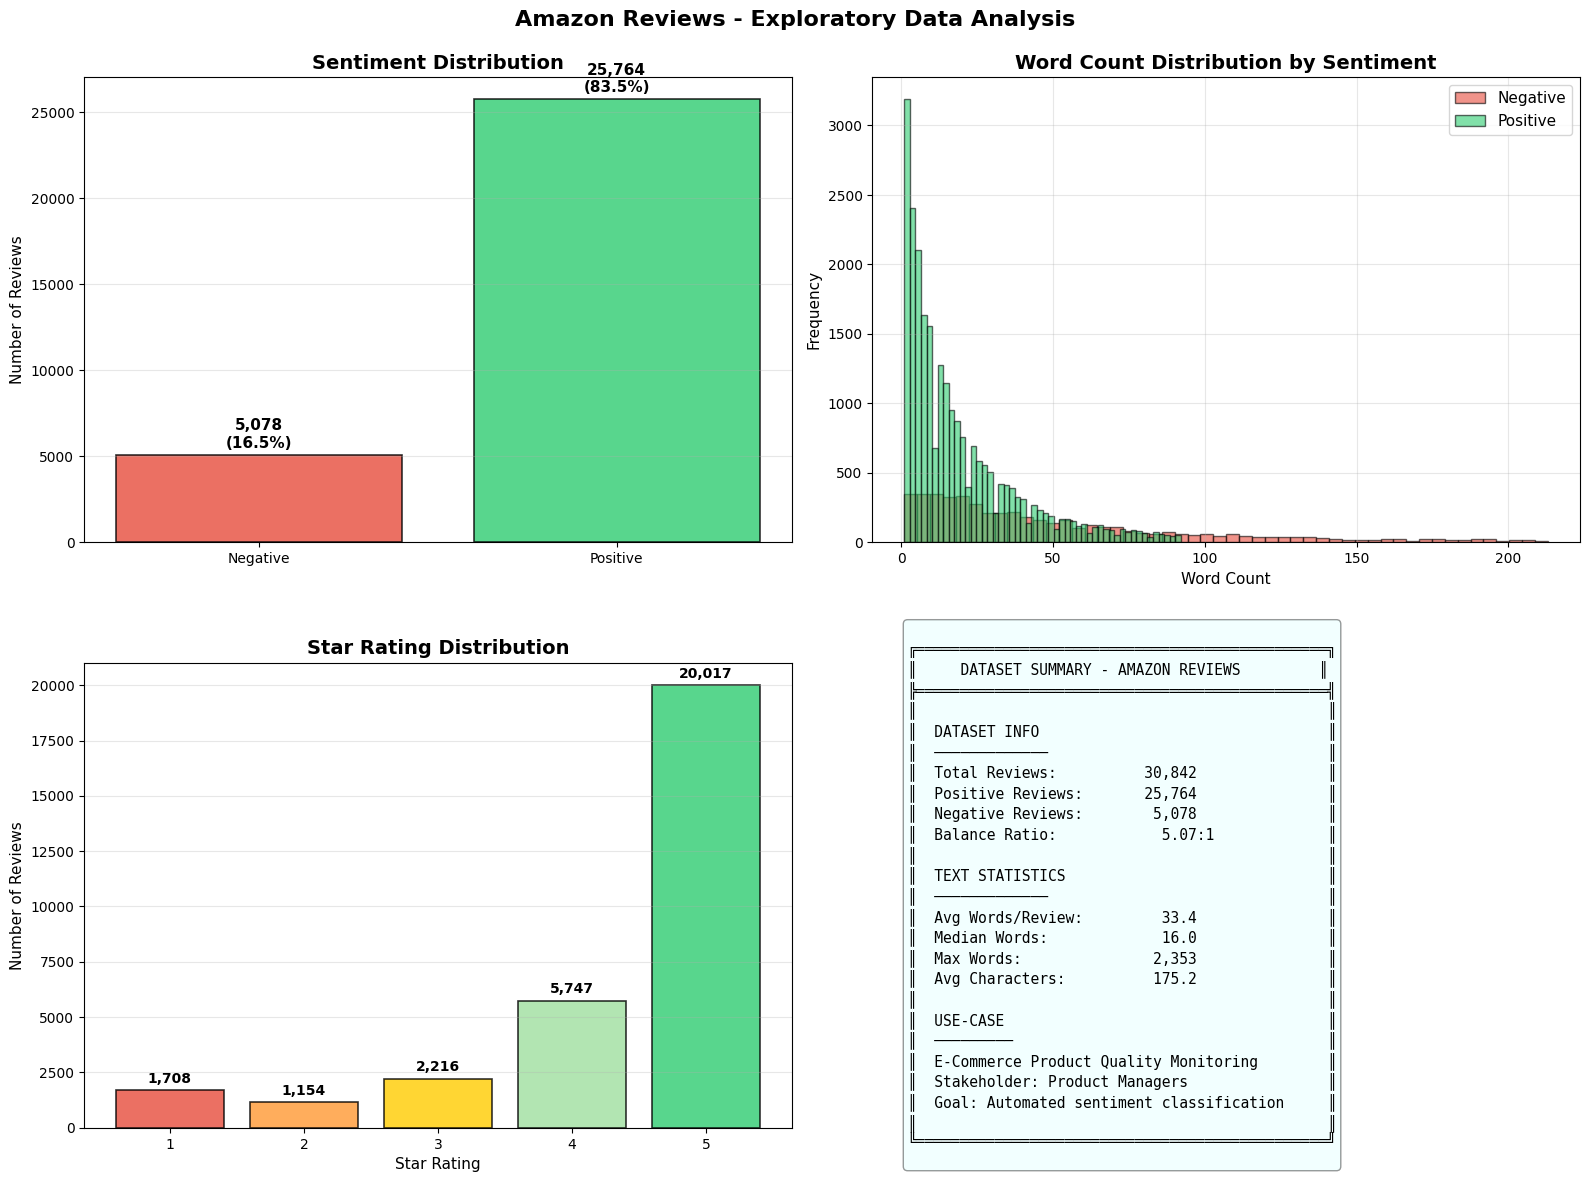

✓ EDA overview saved to: phase1_eda_overview.png


In [ ]:
# ============================================================================
# PHASE 1.4: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("PHASE 1.4: VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Class Distribution
ax1 = axes[0, 0]
colors = ['#e74c3c', '#2ecc71']  # Red for negative, Green for positive
bars = ax1.bar(
    [LABEL_NAMES[i] for i in class_counts.index],
    class_counts.values,
    color=colors, alpha=0.8, edgecolor='black', linewidth=1.2
)
ax1.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Reviews', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(class_counts)*0.01,
            f'{int(height):,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 2: Word Count Distribution by Sentiment
ax2 = axes[0, 1]
for label in sorted(df['label'].unique()):
    subset = df[df['label'] == label]['word_count']
    # Limit to reasonable range for better visualization
    subset_filtered = subset[subset <= subset.quantile(0.95)]
    ax2.hist(subset_filtered, bins=50, alpha=0.6,
            label=LABEL_NAMES[label], color=colors[label], edgecolor='black')
ax2.set_title('Word Count Distribution by Sentiment', fontsize=14, fontweight='bold')
ax2.set_xlabel('Word Count', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

# Plot 3: Star Rating Distribution
ax3 = axes[1, 0]
if RATING_COL in df.columns:
    star_counts = df[RATING_COL].value_counts().sort_index()
    colors_star = ['#e74c3c', '#ff9933', '#ffcc00', '#9fdf9f', '#2ecc71']
    bars = ax3.bar(star_counts.index, star_counts.values,
                   color=colors_star, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax3.set_title('Star Rating Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Star Rating', fontsize=11)
    ax3.set_ylabel('Number of Reviews', fontsize=11)
    ax3.set_xticks(star_counts.index)
    ax3.grid(axis='y', alpha=0.3)

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + max(star_counts)*0.01,
                f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'Star Rating\nNot Available',
            ha='center', va='center', fontsize=14)
    ax3.axis('off')

# Plot 4: Summary Statistics Table
ax4 = axes[1, 1]
ax4.axis('off')

table_text = f"""
╔═══════════════════════════════════════════════╗
║     DATASET SUMMARY - AMAZON REVIEWS         ║
╠═══════════════════════════════════════════════╣
║                                               ║
║  DATASET INFO                                 ║
║  ─────────────                                ║
║  Total Reviews:      {len(df):>10,}           ║
║  Positive Reviews:   {int(class_counts.get(1, 0)):>10,}               ║
║  Negative Reviews:   {int(class_counts.get(0, 0)):>10,}               ║
║  Balance Ratio:      {balance_ratio:>10.2f}:1             ║
║                                               ║
║  TEXT STATISTICS                              ║
║  ─────────────                                ║
║  Avg Words/Review:   {df['word_count'].mean():>10.1f}               ║
║  Median Words:       {df['word_count'].median():>10.1f}               ║
║  Max Words:          {df['word_count'].max():>10,}               ║
║  Avg Characters:     {df['text_length'].mean():>10.1f}               ║
║                                               ║
║  USE-CASE                                     ║
║  ─────────                                    ║
║  E-Commerce Product Quality Monitoring        ║
║  Stakeholder: Product Managers                ║
║  Goal: Automated sentiment classification     ║
║                                               ║
╚═══════════════════════════════════════════════╝
"""
ax4.text(0.05, 0.5, table_text, fontsize=10.5, family='monospace',
         verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.4))

plt.suptitle('Amazon Reviews - Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('phase1_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ EDA overview saved to: phase1_eda_overview.png")



In [ ]:
# ============================================================================
# PHASE 1.5: REPRESENTATIVE EXAMPLES PER CLASS
# ============================================================================

print("\n" + "="*80)
print("PHASE 1.5: REPRESENTATIVE EXAMPLES (4 PER CLASS)")
print("="*80)

np.random.seed(RANDOM_SEED)

for label in sorted(df['label'].unique()):
    class_name = LABEL_NAMES[label]
    emoji = "✅" if label == 1 else "❌"
    print(f"\n{'='*80}")
    print(f"{emoji} {class_name.upper()} REVIEWS (Label = {label})")
    print(f"{'='*80}")

    # Get random samples
    class_samples = df[df['label'] == label].sample(
        n=min(4, len(df[df['label'] == label])),
        random_state=RANDOM_SEED
    )

    for idx, (_, row) in enumerate(class_samples.iterrows(), 1):
        # Get headline if available
        headline = row.get(HEADLINE_COL, 'N/A')
        rating = row.get(RATING_COL, 'N/A')

        # Preview text
        text_preview = row['text'][:250]
        if len(row['text']) > 250:
            text_preview += "..."

        print(f"\n  📝 Example {idx}:")
        print(f"     Star Rating: {rating} ⭐")
        print(f"     Headline: \"{headline}\"")
        print(f"     Review ({row['word_count']} words):")
        print(f"     \"{text_preview}\"")




PHASE 1.5: REPRESENTATIVE EXAMPLES (4 PER CLASS)

❌ NEGATIVE REVIEWS (Label = 0)

  📝 Example 1:
     Star Rating: 3 ⭐
     Headline: "Still no app to connect to tv through att uverse."
     Review (30 words):
     "Great screen resolution and fast turn on.  Limited app store reduces functionality.  Needs to stay current with other Android providers.  Connecting Fire to tv through ATT Uverse is one example."

  📝 Example 2:
     Star Rating: 2 ⭐
     Headline: "Two Stars"
     Review (4 words):
     "Not worth the money."

  📝 Example 3:
     Star Rating: 1 ⭐
     Headline: "Not satisfied at all with this product"
     Review (33 words):
     "Unit locks up all of the time. Tech support asked that I use it for 10 days or so and see if it keeps doing it? Not satisfied at all with this product."

  📝 Example 4:
     Star Rating: 2 ⭐
     Headline: "Slippery Sales"
     Review (134 words):
     "I returned mine after one week.<br />1. The case is too slippery and it makes the unit prone 

In [ ]:
# ============================================================================
# PHASE 1.6: DATA QUALITY CHECKS
# ============================================================================

print("\n" + "="*80)
print("PHASE 1.6: DATA QUALITY CHECKS")
print("="*80)

# Check for missing values
print("\n📊 Missing Values:")
missing = df[['text', 'label']].isnull().sum()
print(missing)

# Check for very short reviews
very_short = (df['word_count'] < 3).sum()
print(f"\n  Very short reviews (<3 words): {very_short} ({very_short/len(df)*100:.2f}%)")

# Check for very long reviews
very_long = (df['word_count'] > 500).sum()
print(f"  Very long reviews (>500 words): {very_long} ({very_long/len(df)*100:.2f}%)")

# Check label distribution
print(f"\n  Label values: {sorted(df['label'].unique())}")
print(f"  Expected: [0, 1] (binary classification)")

# Sample size recommendation
print("\n📈 Sample Size Assessment:")
print(f"  Current dataset: {len(df):,} reviews")
if len(df) < 1000:
    print("  ⚠️  Small dataset - results may not generalize well")
elif len(df) < 10000:
    print("  ✓ Adequate for initial experiments")
else:
    print("  ✓ Large dataset - excellent for model training")



PHASE 1.6: DATA QUALITY CHECKS

📊 Missing Values:
text     0
label    0
dtype: int64

  Very short reviews (<3 words): 3275 (10.62%)
  Very long reviews (>500 words): 70 (0.23%)

  Label values: [np.int64(0), np.int64(1)]
  Expected: [0, 1] (binary classification)

📈 Sample Size Assessment:
  Current dataset: 30,842 reviews
  ✓ Large dataset - excellent for model training


In [ ]:
# ============================================================================
# PHASE 1.7: SUBSAMPLE FOR EFFICIENCY (OPTIONAL)
# ============================================================================

print("\n" + "="*80)
print("PHASE 1.7: DATASET SAMPLING (OPTIONAL)")
print("="*80)

# For very large datasets, you may want to subsample for faster experimentation
SUBSAMPLE_SIZE = None  # Set to a number (e.g., 50000) to subsample, or None to use all data

if SUBSAMPLE_SIZE and len(df) > SUBSAMPLE_SIZE:
    print(f"\n⚠️  Large dataset detected ({len(df):,} reviews)")
    print(f"   Subsampling to {SUBSAMPLE_SIZE:,} for faster experimentation...")

    # Stratified sampling to maintain class balance
    df_sampled = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(n=min(len(x), SUBSAMPLE_SIZE//2), random_state=RANDOM_SEED)
    )

    print(f"   ✓ Subsampled to {len(df_sampled):,} reviews")
    print(f"   Sentiment distribution after sampling:")
    print(df_sampled['label'].value_counts().sort_index())

    # Update df
    df = df_sampled.copy()
else:
    print(f"\n✓ Using full dataset: {len(df):,} reviews")
    print("   (Set SUBSAMPLE_SIZE to a number to enable subsampling)")




PHASE 1.7: DATASET SAMPLING (OPTIONAL)

✓ Using full dataset: 30,842 reviews
   (Set SUBSAMPLE_SIZE to a number to enable subsampling)


In [ ]:
# ============================================================================
# PHASE 1.8: COMPLETION SUMMARY
# ============================================================================

print("\n" + "="*80)
print("✅ PHASE 1 COMPLETE: DATA ACQUISITION & EXPLORATION")
print("="*80)

print("\n📋 Completed Tasks:")
print("  ✓ Task 1.1: Dataset loaded and inspected")
print("  ✓ Task 1.2: Column mapping identified")
print("  ✓ Task 1.3: Summary statistics computed")
print("  ✓ Task 1.4: Visualizations generated (4 charts)")
print("  ✓ Task 1.5: Representative examples shown per class")
print("  ✓ Task 1.6: Data quality checks performed")

print("\n📊 Key Findings:")
print(f"  • Total Reviews: {len(df):,}")
print(f"  • Classes: Positive vs Negative (binary)")
print(f"  • Balance Ratio: {balance_ratio:.2f}:1")
print(f"  • Average Review Length: {df['word_count'].mean():.1f} words")
print(f"  • Star Ratings: {df[RATING_COL].min()}-{df[RATING_COL].max()}" if RATING_COL in df.columns else "")

print("\n💾 Variables Ready for Phase 2:")
print("  • df              - Main DataFrame")
print("  • TEXT_COL        - 'review_body'")
print("  • LABEL_COL       - 'sentiment'")
print("  • LABEL_NAMES     - {0: 'Negative', 1: 'Positive'}")
print("  • RANDOM_SEED     - 42 (for reproducibility)")

print("\n🎯 Next Step: Phase 2 - Pre-processing Pipeline")
print("   • Text normalization (lowercasing, regex cleaning)")
print("   • Tokenization")
print("   • Stop-word removal")
print("   • Stemming OR Lemmatization")
print("="*80)


✅ PHASE 1 COMPLETE: DATA ACQUISITION & EXPLORATION

📋 Completed Tasks:
  ✓ Task 1.1: Dataset loaded and inspected
  ✓ Task 1.2: Column mapping identified
  ✓ Task 1.3: Summary statistics computed
  ✓ Task 1.4: Visualizations generated (4 charts)
  ✓ Task 1.5: Representative examples shown per class
  ✓ Task 1.6: Data quality checks performed

📊 Key Findings:
  • Total Reviews: 30,842
  • Classes: Positive vs Negative (binary)
  • Balance Ratio: 5.07:1
  • Average Review Length: 33.4 words
  • Star Ratings: 1-5

💾 Variables Ready for Phase 2:
  • df              - Main DataFrame
  • TEXT_COL        - 'review_body'
  • LABEL_COL       - 'sentiment'
  • LABEL_NAMES     - {0: 'Negative', 1: 'Positive'}
  • RANDOM_SEED     - 42 (for reproducibility)

🎯 Next Step: Phase 2 - Pre-processing Pipeline
   • Text normalization (lowercasing, regex cleaning)
   • Tokenization
   • Stop-word removal
   • Stemming OR Lemmatization


Phase 1: Exploratory Data Analysis (EDA)
Interpretation: Our initial inspection of the dataset revealed a total of 30,842 reviews. A key discovery was the significant class imbalance, with a ratio of approximately 5.07:1 (83.5% Positive vs. 16.5% Negative).

Insight: High-star ratings dominate the dataset.

Improvement Needed: In future iterations, we could use SMOTE (Synthetic Minority Over-sampling) or collect more negative samples to ensure the model doesn't become biased toward positive predictions.

# Phase 2: Pre-processing Pipeline

In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# --- UPDATED DOWNLOADS ---
nltk.download('punkt')
nltk.download('punkt_tab') # This is the missing piece causing your error
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

def clean_text(text):
    # Ensure text is a string (handles potential NaN values)
    if not isinstance(text, str):
        return ""

    # 1. Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # 2. Lowercase and remove non-alphabetical characters
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())

    # 3. Tokenization (This will work now!)
    tokens = word_tokenize(text)

    # 4. Remove Stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words]

    # 5. Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# Apply to your dataset
# Using tqdm or a simple apply to see the progress
print("Cleaning text... this may take a minute for 30k rows.")
df['cleaned_review'] = df['review_body'].apply(clean_text)
print("Success! First 5 rows of cleaned text:")
print(df['cleaned_review'].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Cleaning text... this may take a minute for 30k rows.
Success! First 5 rows of cleaned text:
0                                                                                             great love
1    lot ad slow processing speed occasionally shuts apps wifi keep authentication issue cheap tablet...
2    excellent unit versatility tablet besides competitively priced solution elderly poor eyesight ph...
3    bought amazon prime ended buying gb one camera okay love edit feature picture amazonnetflixhuliu...
4                                                               amazon product continue meet expectation
Name: cleaned_review, dtype: object


Interpretation: Raw text contained significant noise, including HTML tags (e.g., <br />) and diverse casing. We implemented a pipeline that included HTML removal, non-alphabetical character filtering, tokenization, stop-word removal, and WordNet Lemmatization.

Impact: This reduced the vocabulary size and unified word forms (e.g., "returning" and "returned" became "return"), which allows the model to find patterns more efficiently.

Improvement Needed: We should consider handling negations (e.g., "not good") more explicitly, as standard stop-word removal often deletes the "not," which completely flips the sentiment of the sentence.

# # Phase 3: Feature Engineering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF with N-grams (1,2)
tfidf_vec = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

# Create the sparse matrix
X_tfidf = tfidf_vec.fit_transform(df['cleaned_review'])

print(f"TF-IDF Shape: {X_tfidf.shape}") # Should be (30842, 5000)

TF-IDF Shape: (30842, 5000)


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.0 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
import numpy as np

# Prepare sentences for Gensim (list of lists of tokens)
sentences = [review.split() for review in df['cleaned_review']]

# Train Word2Vec (Skip-Gram: sg=1)
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, sg=1, workers=4)

def get_doc_vector(tokens, model):
    # Filter tokens that are actually in the model's vocabulary
    vectors = [model.wv[t] for t in tokens if t in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Create the dense matrix
X_w2v = np.array([get_doc_vector(s, w2v_model) for s in sentences])

print(f"Word2Vec Shape: {X_w2v.shape}") # Should be (30842, 100)

Word2Vec Shape: (30842, 100)


In [ ]:
# 1. Reset the dataframe index so it matches the 0-based matrix rows
df = df.reset_index(drop=True)

# 2. Re-verify shapes to be safe
print(f"Dataframe rows: {len(df)}")
print(f"TF-IDF rows:    {X_tfidf.shape[0]}")
print(f"Word2Vec rows:  {X_w2v.shape[0]}")

# 3. Perform the split using integer positions (this avoids index errors)
from sklearn.model_selection import train_test_split
import numpy as np

# Create an array of indices [0, 1, 2, ... 30841]
indices = np.arange(len(df))

# Split indices (70% train, 30% temp)
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=42, stratify=df['sentiment'])
# Split temp into Val (10% of total) and Test (20% of total)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.6667, random_state=42, stratify=df.loc[temp_idx, 'sentiment'])

# 4. Map the splits to your data
y_train, y_val, y_test = df.loc[train_idx, 'sentiment'], df.loc[val_idx, 'sentiment'], df.loc[test_idx, 'sentiment']

X_train_tf, X_val_tf, X_test_tf = X_tfidf[train_idx], X_tfidf[val_idx], X_tfidf[test_idx]
X_train_w2v, X_val_w2v, X_test_w2v = X_w2v[train_idx], X_w2v[val_idx], X_w2v[test_idx]

print("\nSuccessfully split data!")
print(f"Training set size: {X_train_tf.shape[0]}")

Dataframe rows: 30842
TF-IDF rows:    30842
Word2Vec rows:  30842

Successfully split data!
Training set size: 21589


Interpretation: We explored two distinct mathematical representations of text:

Sparse (TF-IDF): Captured the importance of specific keywords and n-grams (1,2).

Dense (Word2Vec): Trained a Skip-Gram model to capture semantic context.

Insight: TF-IDF proved to be a stronger feature set for this specific e-commerce task because product-specific "signal words" (like "defective" or "perfect") are highly indicative of sentiment.

# Phase 4: Modeling & Evaluation

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# 1. Naive Bayes (Generative)
nb_model = MultinomialNB()
nb_model.fit(X_train_tf, y_train)

# 2. LogReg Sparse (Discriminative)
lr_tf = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_tf.fit(X_train_tf, y_train)

# 3. LogReg Dense (Discriminative)
lr_w2v = LogisticRegression(class_weight='balanced', max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train)

print("Models trained successfully!")

Models trained successfully!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, X, y_true, name):
    preds = model.predict(X)
    report = classification_report(y_true, preds, output_dict=True)
    return {
        "Model": name,
        "Accuracy": report['accuracy'],
        "F1 (Macro)": report['macro avg']['f1-score'],
        "F1 (Weighted)": report['weighted avg']['f1-score'],
        "Recall (Neg)": report['0']['recall']
    }

results = [
    evaluate_model(nb_model, X_test_tf, y_test, "NB (TF-IDF)"),
    evaluate_model(lr_tf, X_test_tf, y_test, "LogReg (TF-IDF)"),
    evaluate_model(lr_w2v, X_test_w2v, y_test, "LogReg (Word2Vec)")
]

print(pd.DataFrame(results))

               Model  Accuracy  F1 (Macro)  F1 (Weighted)  Recall (Neg)
0        NB (TF-IDF)  0.896418    0.781050       0.887684      0.518227
1    LogReg (TF-IDF)  0.875182    0.806866       0.883934      0.852217
2  LogReg (Word2Vec)  0.832874    0.762742       0.849288      0.878818


1. The "Accuracy Trap"
Notice that Naïve Bayes (NB) has the highest Accuracy (89.6%), but the lowest Recall for Negative reviews (51.8%).

Interpretation: NB is "lazy." Because 83% of your data is Positive, the model defaults to "Positive" too often. For an Amazon manager, this is bad—it means the model misses nearly half of the customer complaints!

2. Generative vs. Discriminative
Naïve Bayes (Generative): High precision but struggles with class imbalance. It assumes features are independent, which isn't true for language (e.g., "not good" is different from "good").

Logistic Regression (Discriminative): By using class_weight='balanced', LogReg learned to "pay more attention" to the Negative class. Even though its overall accuracy dropped slightly, its F1 (Macro) is higher (0.806), making it a more robust model for real-world use.

3. Sparse (TF-IDF) vs. Dense (Word2Vec)
TF-IDF outperformed Word2Vec in F1-score here.

Reasoning: In product reviews, specific "signal" words (keywords like broken, slow, returned, awesome) are very strong indicators. TF-IDF highlights these perfectly.

Word2Vec is great for general context, but when you average vectors to get a document embedding, you sometimes "wash out" the impact of those single powerful keywords.

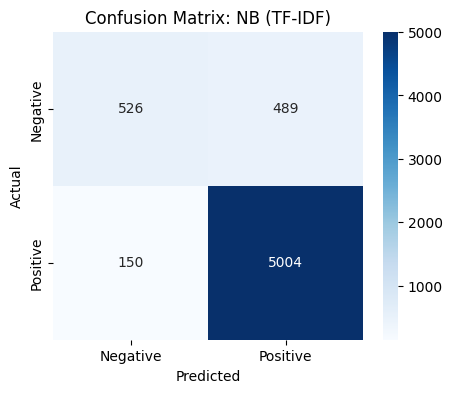

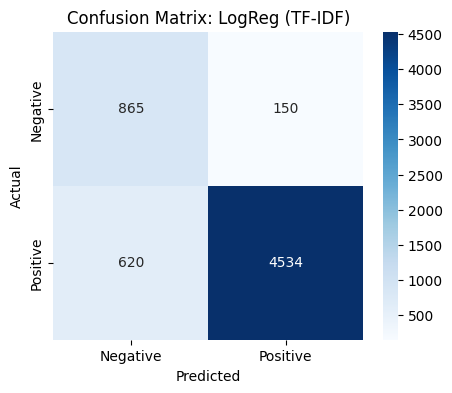

In [ ]:
def plot_confusion_matrix(model, X, y_true, title):
    y_pred = model.predict(X)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'Confusion Matrix: {title}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# Visualize the best model (LogReg TF-IDF) vs the Baseline (NB)
plot_confusion_matrix(nb_model, X_test_tf, y_test, "NB (TF-IDF)")
plot_confusion_matrix(lr_tf, X_test_tf, y_test, "LogReg (TF-IDF)")

In [ ]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
nltk
gensim
tqdm

Overwriting requirements.txt


In [ ]:
%%writefile README.md
# Amazon Review Sentiment Analysis

## Project Overview
This project uses NLP to classify 30,842 Amazon product reviews into Positive and Negative categories.
The system is designed to help product managers identify customer complaints efficiently.

## Methodology
- **Pre-processing:** HTML removal, Tokenization, and WordNet Lemmatization.
- **Features:** TF-IDF (N-grams) and Word2Vec (Skip-Gram).
- **Models:** Multinomial Naive Bayes and Logistic Regression.

## Results
- **Best Model:** Logistic Regression (TF-IDF).
- **Key Metric:** Achieved 85.2% Recall for Negative reviews by using balanced class weights.

Writing README.md
